## Load the Dataset

In [283]:
import pandas as pd
import numpy as np
df=pd.read_csv("D:\AI-Lab-99\Week 3\Module 4 Exploratory Data Analysis (EDA)\customer_personality_cleaned.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Year,Month,Day
0,5524.0,1957.0,Graduation,Single,58138.0,0.0,0.0,2012-09-04,58.0,635.0,...,0.0,0.0,0.0,3.0,11.0,0.0,57.0,2012,9,4
1,2174.0,1954.0,Graduation,Single,46344.0,1.0,1.0,2014-03-08,38.0,11.0,...,0.0,0.0,0.0,3.0,11.0,0.0,60.0,2014,3,8
2,4141.0,1965.0,Graduation,Married,71613.0,0.0,0.0,2013-08-21,26.0,426.0,...,0.0,0.0,0.0,3.0,11.0,0.0,49.0,2013,8,21
3,6182.0,1984.0,Graduation,Married,26646.0,1.0,0.0,2014-02-10,26.0,11.0,...,0.0,0.0,0.0,3.0,11.0,0.0,30.0,2014,2,10
4,5324.0,1981.0,Phd,Married,58293.0,1.0,0.0,2014-01-19,94.0,173.0,...,0.0,0.0,0.0,3.0,11.0,0.0,33.0,2014,1,19


## Task 1: Customer Feature Creation

* **Customer Age Column**

In [284]:
# Customer Age
reference_year = 2014
df["Customer_Age"] = reference_year - df["Year_Birth"]
print("Verificatio")
df[["Year_Birth", "Customer_Age"]].head()



Verificatio


,Year_Birth,Customer_Age
0,1957.0,57.0
1,1954.0,60.0
2,1965.0,49.0
3,1984.0,30.0
4,1981.0,33.0


In [285]:
df['Dt_Customer'].dtypes

<StringDtype(na_value=nan)>

* **Customer Tenure**

In [286]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%Y-%m-%d")
df['Customer_Tenure']=reference_year-df['Dt_Customer'].dt.year
print("Verification")
df[['Dt_Customer','Customer_Tenure']].head()


Verification


,Dt_Customer,Customer_Tenure
0,2012-09-04,2
1,2014-03-08,0
2,2013-08-21,1
3,2014-02-10,0
4,2014-01-19,0


* **Total Children**

In [287]:
df['Total_Children']=df['Kidhome'] + df['Teenhome']
print("Verification")
df['Total_Children'].head()

Verification


0    0.0
1    2.0
2    0.0
3    1.0
4    1.0
Name: Total_Children, dtype: float64

* **Family Size**

In [288]:
df['Partner']=np.where(df['Marital_Status'].isin(['Married','Together']),2,1)
df['Family_size']=df['Partner'] + df['Total_Children']
print("Verification")
df['Family_size'].head()

Verification


0    1.0
1    3.0
2    2.0
3    3.0
4    3.0
Name: Family_size, dtype: float64

* **Total Spending**

In [289]:
Spending_column=[
    'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds'
]
df['Total_spending']=df[Spending_column].sum(axis=1)

print("Verification")
df['Total_spending'].head()


Verification


0    1551.5
1      27.0
2     776.0
3      53.0
4     422.0
Name: Total_spending, dtype: float64

* **Total Purchases**

In [290]:
Purchase_column=[
     'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases'
]

df['Total_Purchase']=df[Purchase_column].sum(axis=1)

print("Verification")
df['Total_Purchase'].head()

Verification


0    25.0
1     6.0
2    21.0
3     8.0
4    19.0
Name: Total_Purchase, dtype: float64

* **Total Campaign Acceptance**

In [291]:
df['Total_Campaign']=(
df['AcceptedCmp3'] +
df['AcceptedCmp4'] +
df['AcceptedCmp5'] +
df['AcceptedCmp1']
)

print("Verification")

df['Total_Campaign'].head()

Verification


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Total_Campaign, dtype: float64

* **Average Spending per Purchase**

In [292]:
df['Average Spending per Purchase']=(
    df['Total_spending'] /
    df['Total_Purchase'].replace(0,1)
)
print("Verification")
df['Average Spending per Purchase'].head()

Verification


0    62.060000
1     4.500000
2    36.952381
3     6.625000
4    22.210526
Name: Average Spending per Purchase, dtype: float64

* **Digital Engagement**

In [293]:
df["Digital_Engagement"] = (
    df["NumWebPurchases"] +
    df["NumWebVisitsMonth"]
)
print("Verification")
df['Digital_Engagement'].head()

Verification


0    15.0
1     6.0
2    12.0
3     8.0
4    10.0
Name: Digital_Engagement, dtype: float64

* **Deal Dependency**

In [294]:
df['Deal_Dependency'] = df['NumDealsPurchases'] / df['Total_Purchase']
df['Deal_Dependency'] = df['Deal_Dependency'].fillna(0)
print("Verification")
df['Deal_Dependency'].head()

Verification


0    0.120000
1    0.333333
2    0.047619
3    0.250000
4    0.263158
Name: Deal_Dependency, dtype: float64

In [295]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Year', 'Month', 'Day', 'Customer_Age', 'Customer_Tenure',
       'Total_Children', 'Partner', 'Family_size', 'Total_spending',
       'Total_Purchase', 'Total_Campaign', 'Average Spending per Purchase',
       'Digital_Engagement', 'Deal_Dependency'],
      dtype='str')

* **Preferred Shopping Channel**

In [296]:
purchae_channel=[
        'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases'
]
df['Preferred_Shopping_Channel']=df[purchae_channel].idxmax(axis=1)

df['Preferred_Shopping_Channel'] = df['Preferred_Shopping_Channel'].str.replace('Num', '').str.replace('Purchases', '')

print("Verification")
df['Preferred_Shopping_Channel'].head()

Verification


0    Catalog
1      Store
2      Store
3      Store
4      Store
Name: Preferred_Shopping_Channel, dtype: str

* **Product Preference**


In [297]:
df['Product_Preference']=df[Spending_column].idxmax(axis=1)
df['Product_Preference'] = df['Product_Preference'].str.replace('Mnt', '')
print("Verification")

df['Product_Preference'].head()

Verification


0           Wines
1           Wines
2           Wines
3    MeatProducts
4           Wines
Name: Product_Preference, dtype: str

* **Customer Activity Level**

In [298]:
total_activity = df['NumWebVisitsMonth'] + df['NumWebPurchases'] + df['NumStorePurchases'] + df['NumCatalogPurchases']


df['Customer_Activity_Level'] = pd.qcut(total_activity, q=3, labels=['Low', 'Medium', 'High'])

print("Verification")
df['Customer_Activity_Level'].head()


Verification


0      High
1       Low
2      High
3       Low
4    Medium
Name: Customer_Activity_Level, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

## Task 2: Categorical Feature Encoding

* **Identify categorical columns.**

In [299]:
cat_col=(df.select_dtypes(include=['object']).columns.tolist())
print("Categorical Columns.")
print(cat_col)

Categorical Columns.
['Education', 'Marital_Status', 'Preferred_Shopping_Channel', 'Product_Preference']


C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_12216\2761116364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=(df.select_dtypes(include=['object']).columns.tolist())


* **Apply appropriate encoding techniques (Label Encoding or One-Hot Encoding).**

In [300]:
df['Education'].unique()

<ArrowStringArray>
['Graduation', 'Phd', 'Master', 'Basic', '2N Cycle']
Length: 5, dtype: str

In [301]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
le=LabelEncoder()
encoded_df=df.copy()

oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
encoded_df['Customer_Activity_Level'] = oe.fit_transform(encoded_df[['Customer_Activity_Level']])

oe_education = OrdinalEncoder(categories=[['Basic', '2N Cycle','Graduation', 'Master', 'Phd']])
encoded_df['Education'] = oe_education.fit_transform(encoded_df[['Education']])
for col in cat_col: 
    if col in ['Customer_Activity_Level', 'Education']:
        continue  
    
    encoded_df[col] = le.fit_transform(encoded_df[col])


encoded_df.head()




,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Family_size,Total_spending,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level
0,5524.0,1957.0,2.0,3,58138.0,0.0,0.0,2012-09-04,58.0,635.0,...,1.0,1551.5,25.0,0.0,62.060000,15.0,0.120000,0,5,2.0
1,2174.0,1954.0,2.0,3,46344.0,1.0,1.0,2014-03-08,38.0,11.0,...,3.0,27.0,6.0,0.0,4.500000,6.0,0.333333,1,5,0.0
2,4141.0,1965.0,2.0,2,71613.0,0.0,0.0,2013-08-21,26.0,426.0,...,2.0,776.0,21.0,0.0,36.952381,12.0,0.047619,1,5,2.0
3,6182.0,1984.0,2.0,2,26646.0,1.0,0.0,2014-02-10,26.0,11.0,...,3.0,53.0,8.0,0.0,6.625000,8.0,0.250000,1,3,0.0
4,5324.0,1981.0,4.0,2,58293.0,1.0,0.0,2014-01-19,94.0,173.0,...,3.0,422.0,19.0,0.0,22.210526,10.0,0.263158,1,5,1.0


* **Compare encoded and original features**

In [302]:
comparison = pd.DataFrame({
    "Original": df["Education"],
    "Encoded": encoded_df["Education"]
})

comparison.head()

,Original,Encoded
0,Graduation,2.0
1,Graduation,2.0
2,Graduation,2.0
3,Graduation,2.0
4,Phd,4.0


In [303]:
encoded_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Year', 'Month', 'Day', 'Customer_Age', 'Customer_Tenure',
       'Total_Children', 'Partner', 'Family_size', 'Total_spending',
       'Total_Purchase', 'Total_Campaign', 'Average Spending per Purchase',
       'Digital_Engagement', 'Deal_Dependency', 'Preferred_Shopping_Channel',
       'Product_Preference', 'Customer_Activity_Level'],
      dtype='str')

## Task 3: Feature Selection

In [304]:
drop_col=[
    'ID', 'Year_Birth', 'Kidhome',
    'Teenhome', 'Dt_Customer',
    'Z_CostContact', 'Z_Revenue'
    ]

df_clustring=encoded_df.drop(columns=drop_col,errors='ignore')

print("Selected Features")

selected_features=df_clustring.columns.tolist()
print(selected_features)


Selected Features
['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Year', 'Month', 'Day', 'Customer_Age', 'Customer_Tenure', 'Total_Children', 'Partner', 'Family_size', 'Total_spending', 'Total_Purchase', 'Total_Campaign', 'Average Spending per Purchase', 'Digital_Engagement', 'Deal_Dependency', 'Preferred_Shopping_Channel', 'Product_Preference', 'Customer_Activity_Level']


## Task 4: Skewness and Feature Transformation

In [305]:
num_col=df_clustring.select_dtypes(include=np.number).columns

print("Skewness Before Transformation")

print(df_clustring[num_col].skew().sort_values(ascending=False))

Skewness Before Transformation
Average Spending per Purchase    4.882025
MntFruits                        1.233953
MntFishProducts                  1.230822
MntMeatProducts                  1.213585
MntSweetProducts                 1.213346
MntGoldProds                     1.111307
NumDealsPurchases                1.100205
MntWines                         1.096611
NumCatalogPurchases              1.071866
Total_spending                   0.753781
NumWebPurchases                  0.710853
NumStorePurchases                0.702237
Deal_Dependency                  0.667993
Marital_Status                   0.497219
Total_Children                   0.415970
Digital_Engagement               0.405248
Total_Purchase                   0.183713
Education                        0.126241
Age                              0.120199
Customer_Age                     0.120199
Income                           0.090027
Family_size                      0.088042
Preferred_Shopping_Channel       0.073297
Cus

In [306]:
df_transform=df_clustring.copy()

for col in num_col:
    if abs(df_clustring[col].skew())>0.5:
        df_transform[col]=np.log1p(df_clustring[col])
        print(f"\n Log Transformation apply on {col} successfully .")

# 4. Transformation ke BAAD ki skewness check karein
print("\n--- Skewness After Transformation ---")
print(df_transform[num_col].skew())


 Log Transformation apply on MntWines successfully .

 Log Transformation apply on MntFruits successfully .

 Log Transformation apply on MntMeatProducts successfully .

 Log Transformation apply on MntFishProducts successfully .

 Log Transformation apply on MntSweetProducts successfully .

 Log Transformation apply on MntGoldProds successfully .

 Log Transformation apply on NumDealsPurchases successfully .

 Log Transformation apply on NumWebPurchases successfully .

 Log Transformation apply on NumCatalogPurchases successfully .

 Log Transformation apply on NumStorePurchases successfully .

 Log Transformation apply on Partner successfully .

 Log Transformation apply on Total_spending successfully .

 Log Transformation apply on Average Spending per Purchase successfully .

 Log Transformation apply on Deal_Dependency successfully .

 Log Transformation apply on Product_Preference successfully .

--- Skewness After Transformation ---
Education                        0.126241
Mar

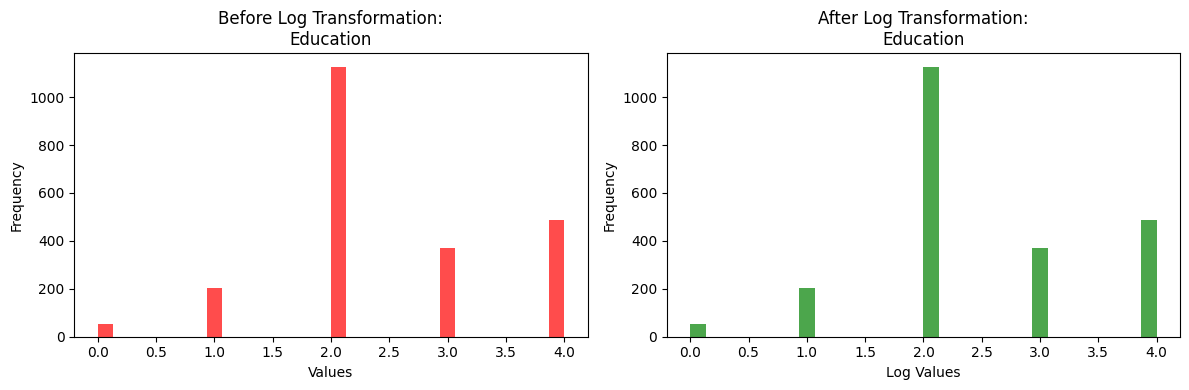

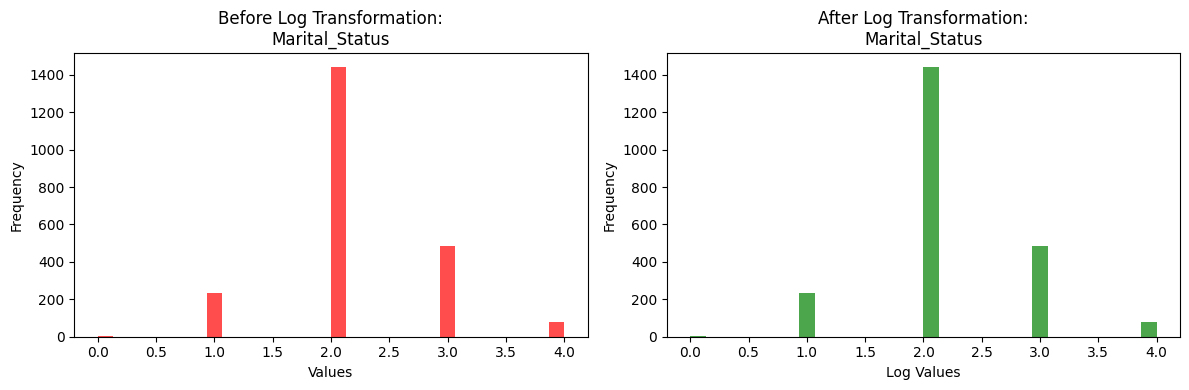

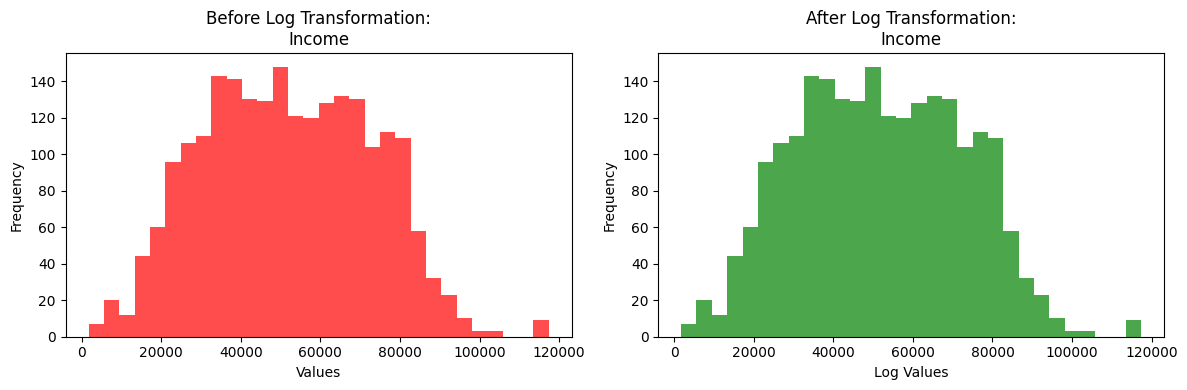

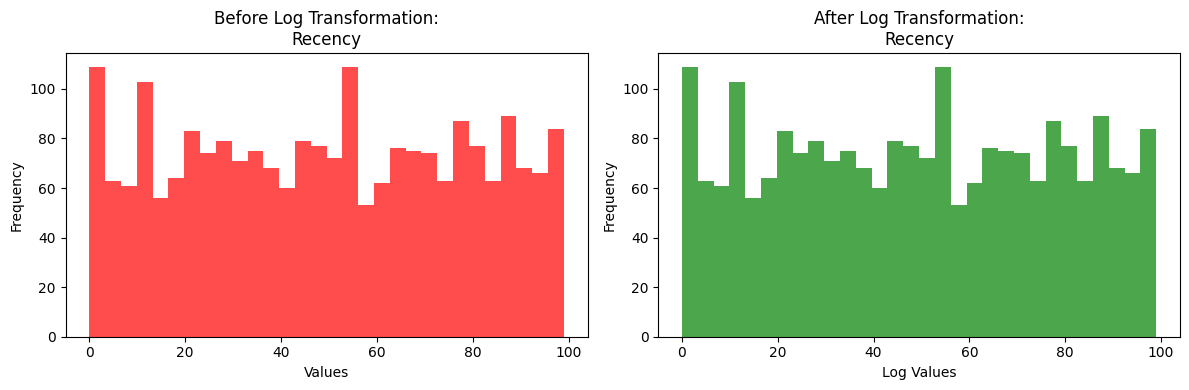

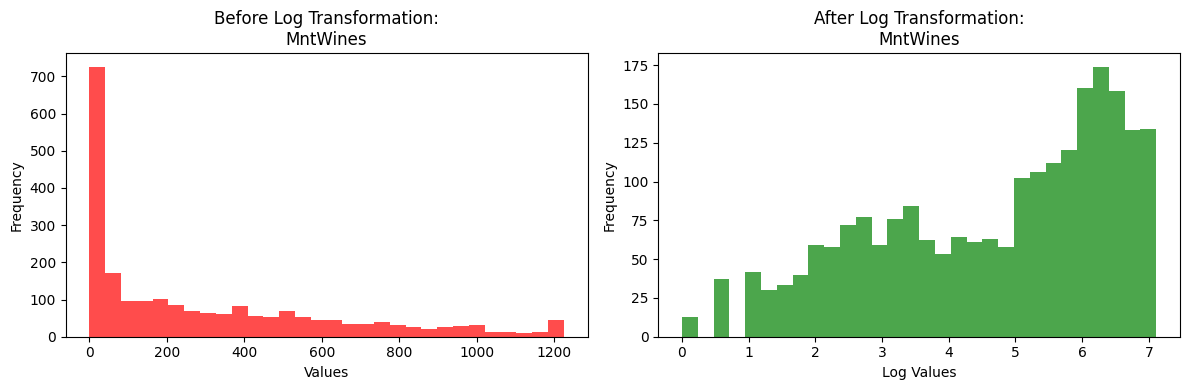

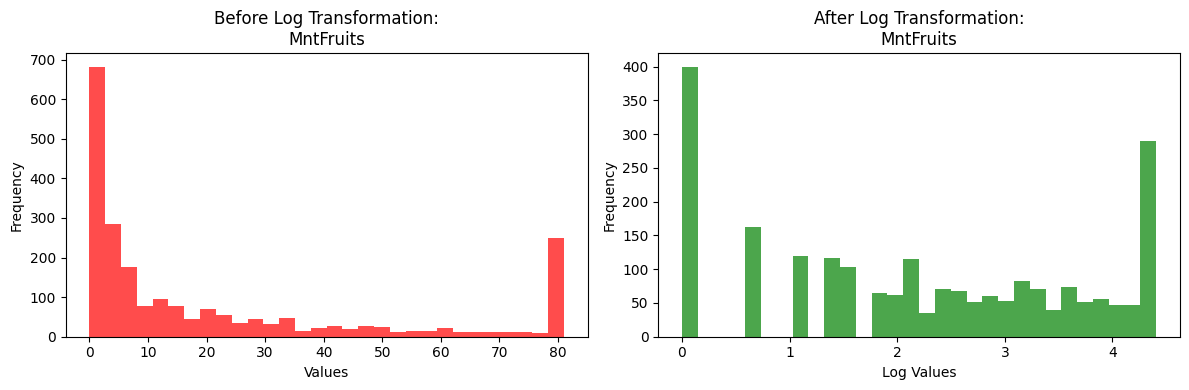

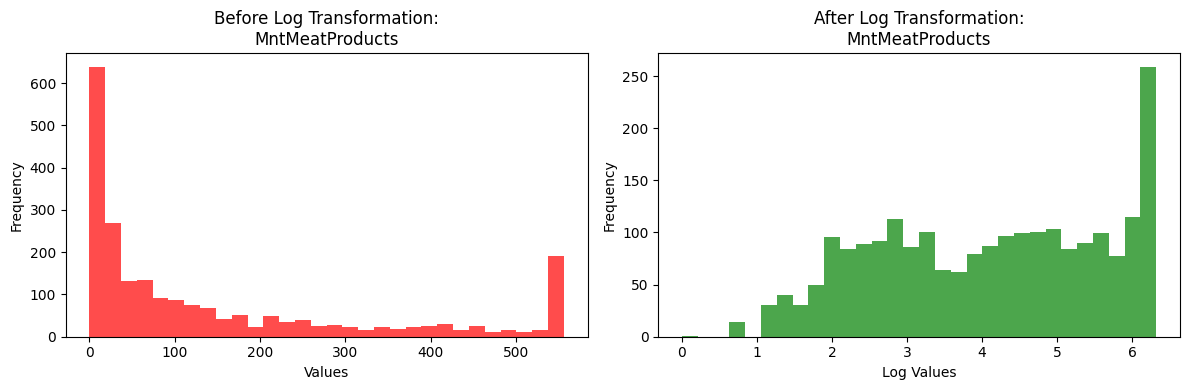

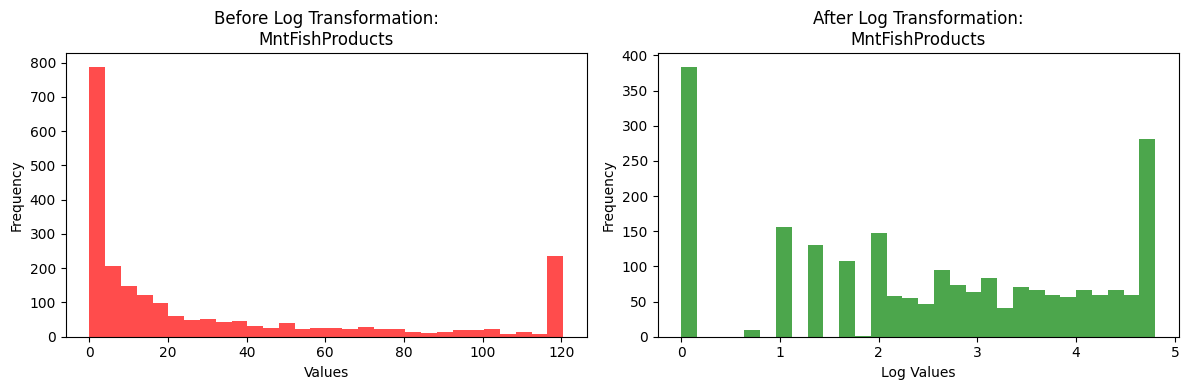

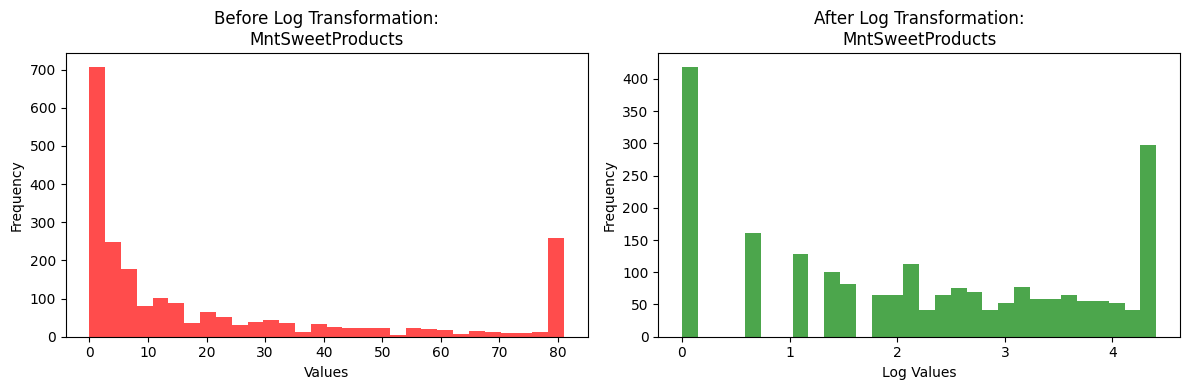

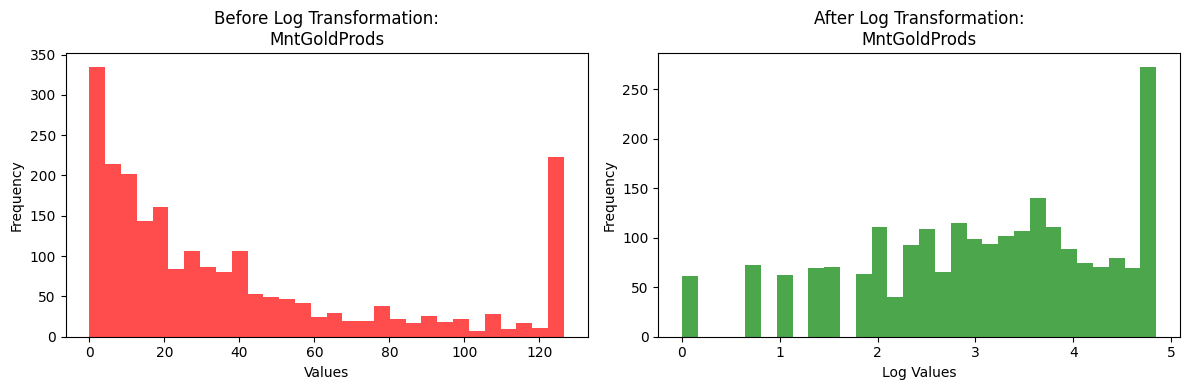

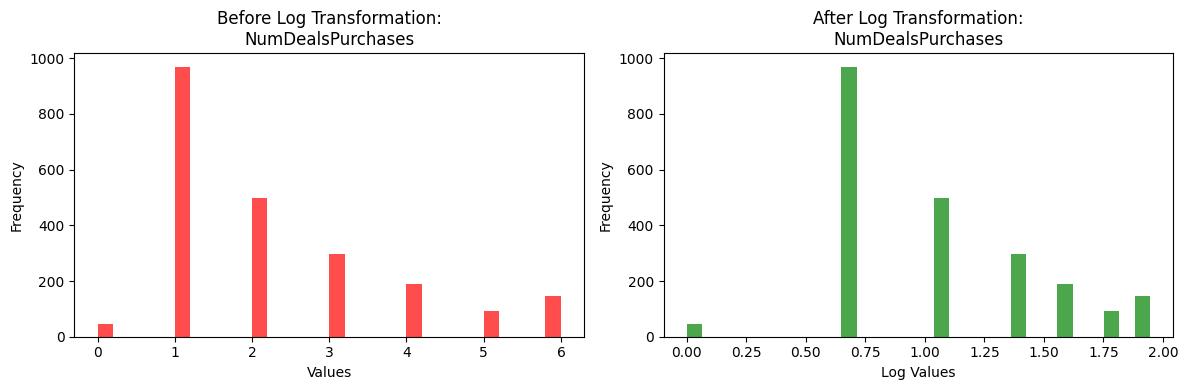

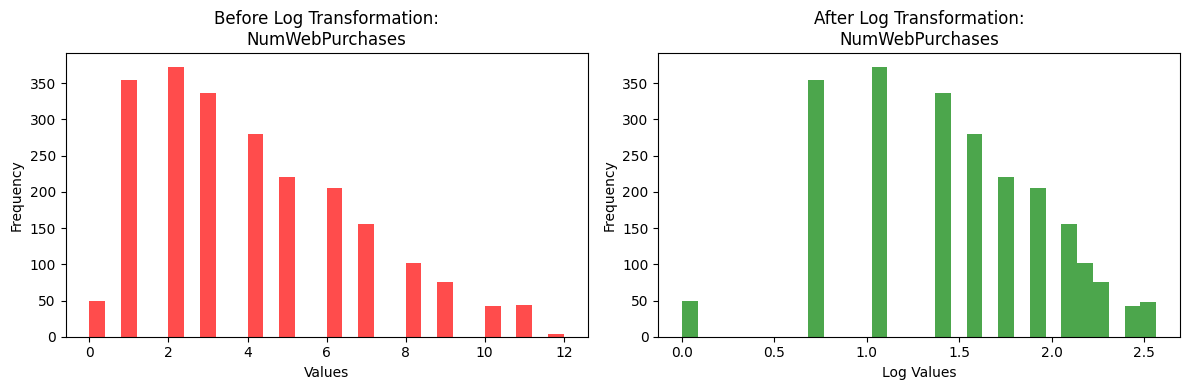

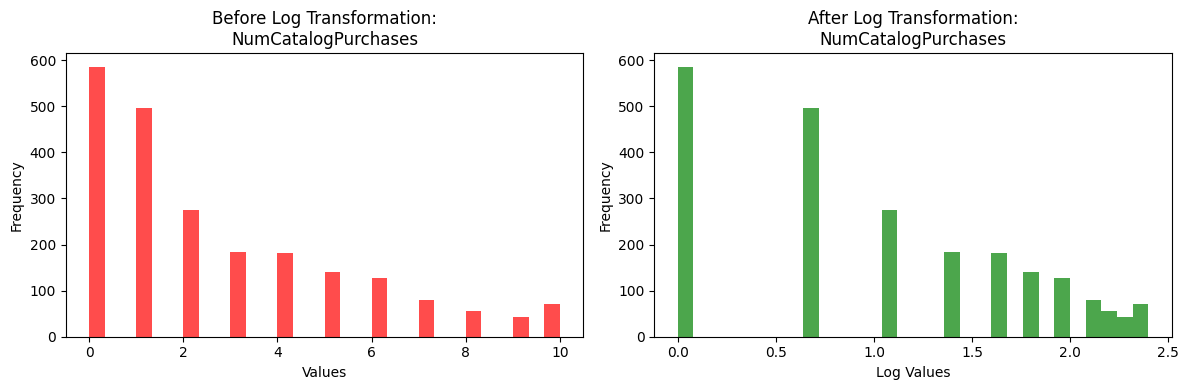

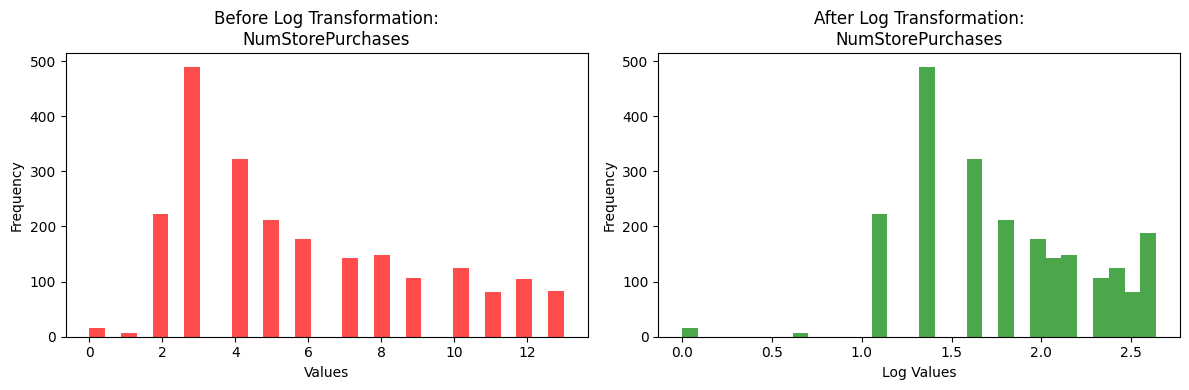

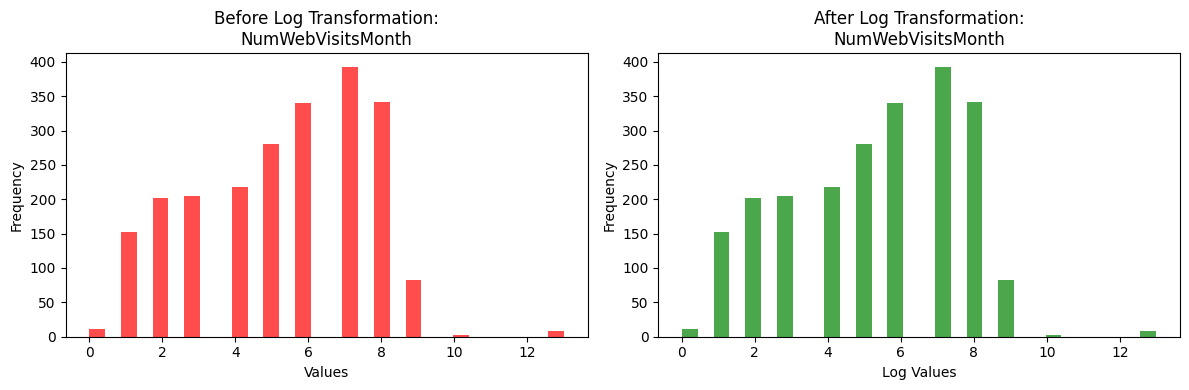

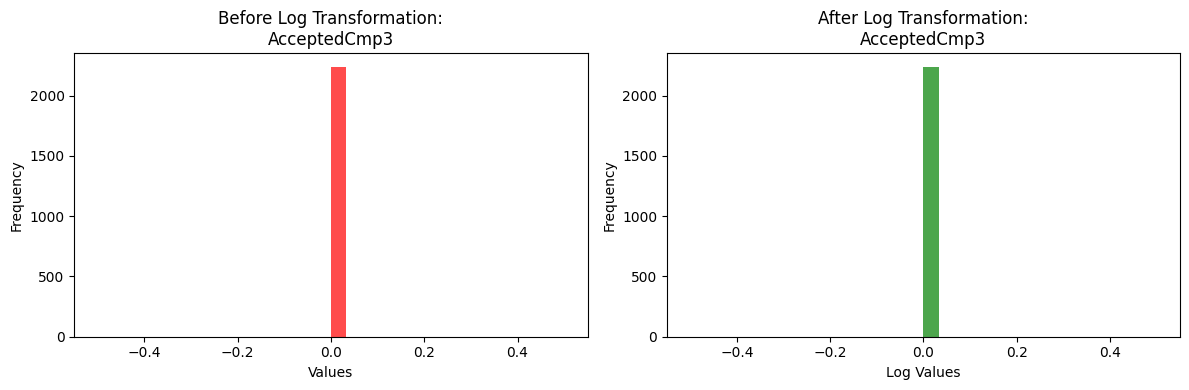

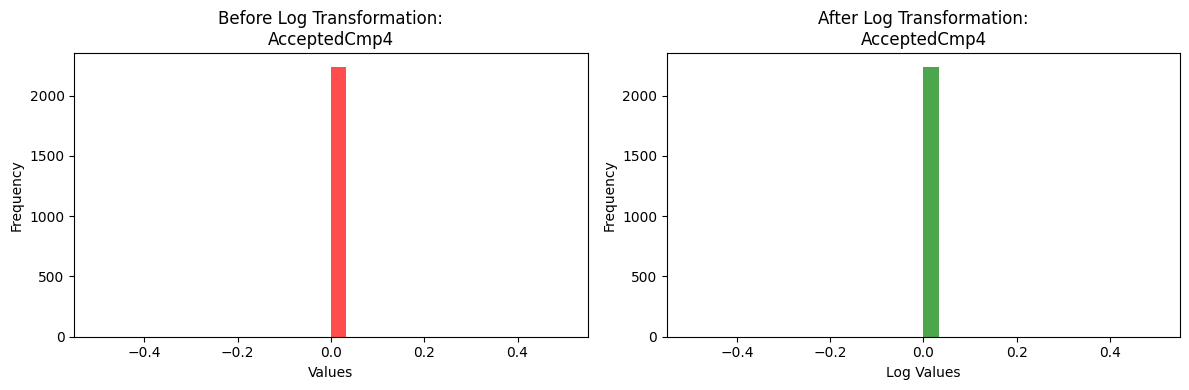

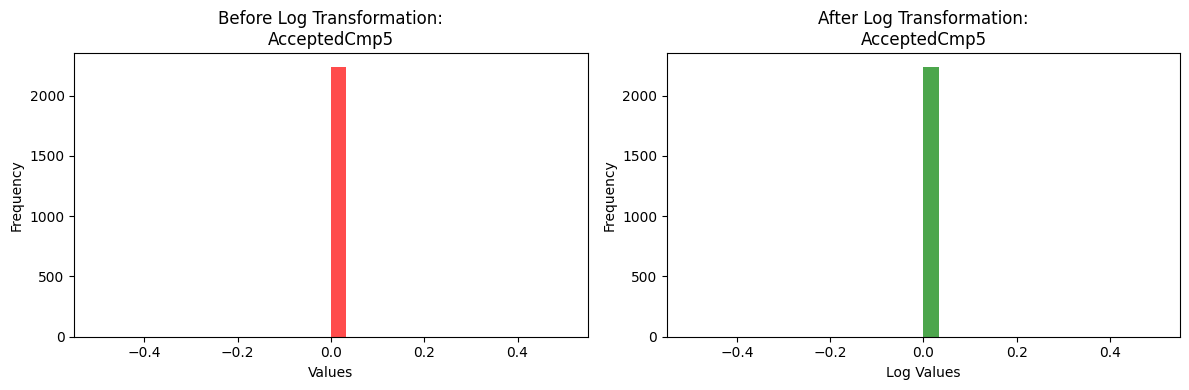

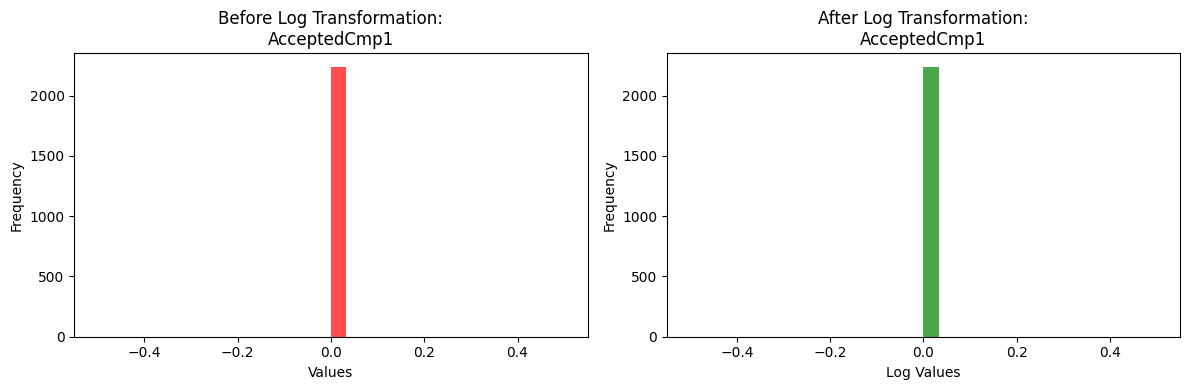

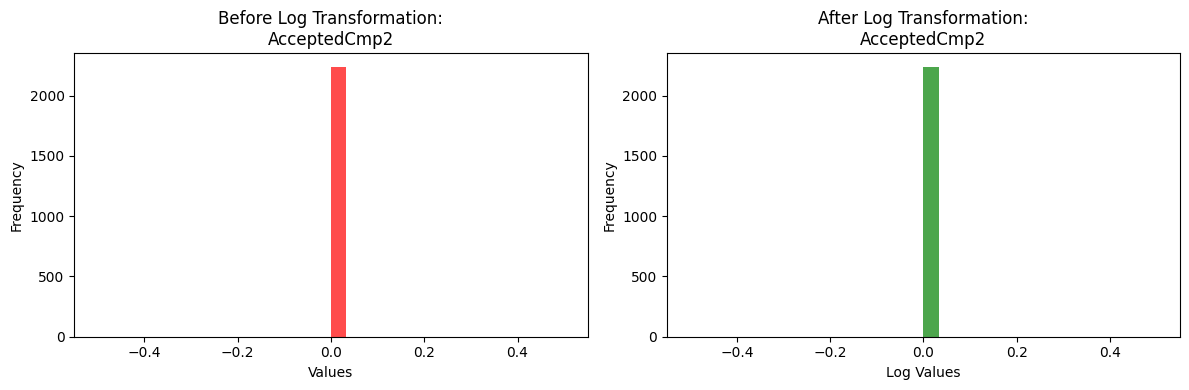

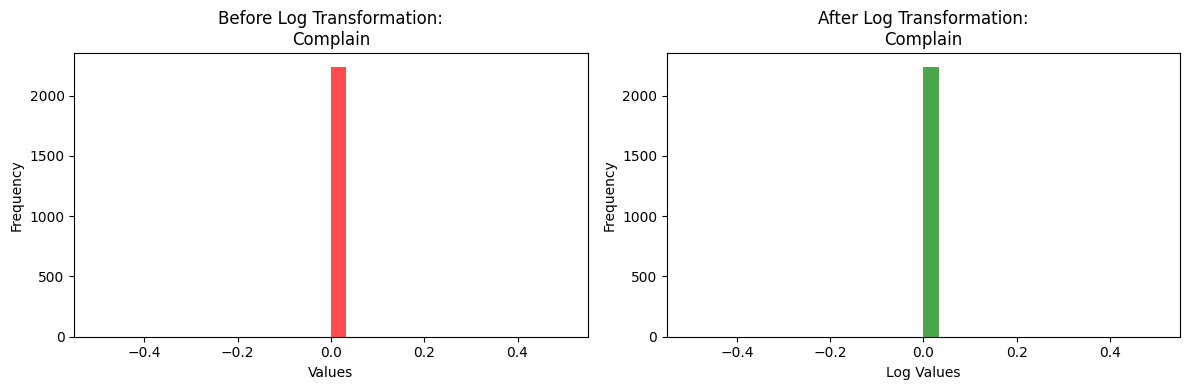

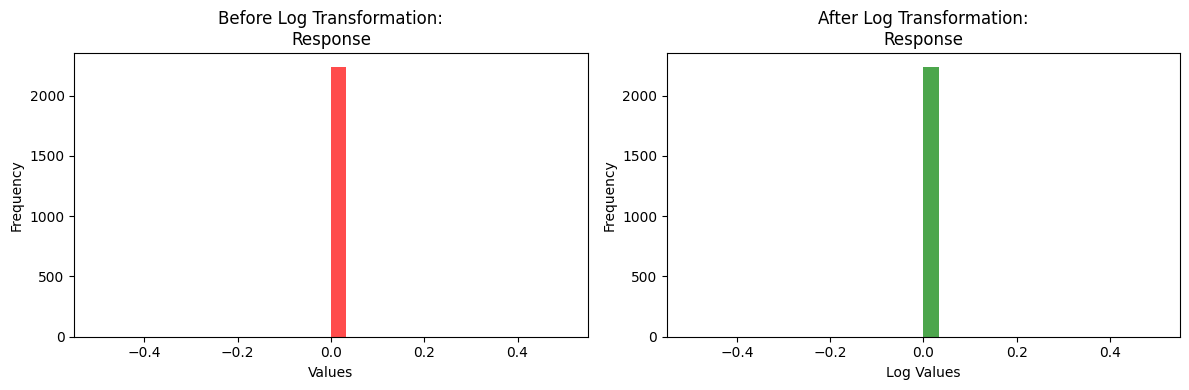

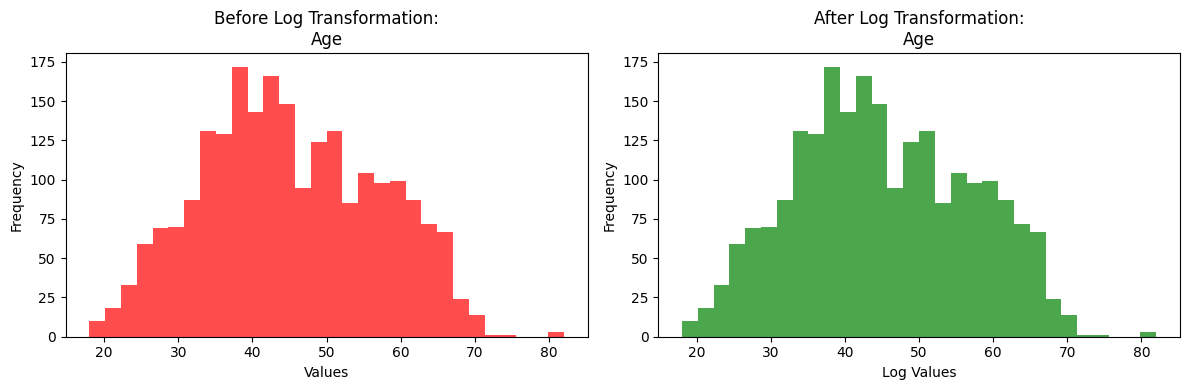

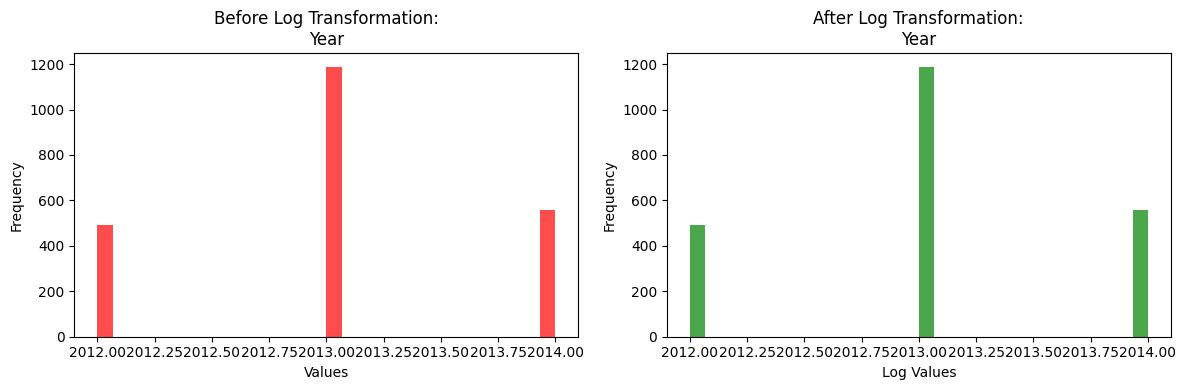

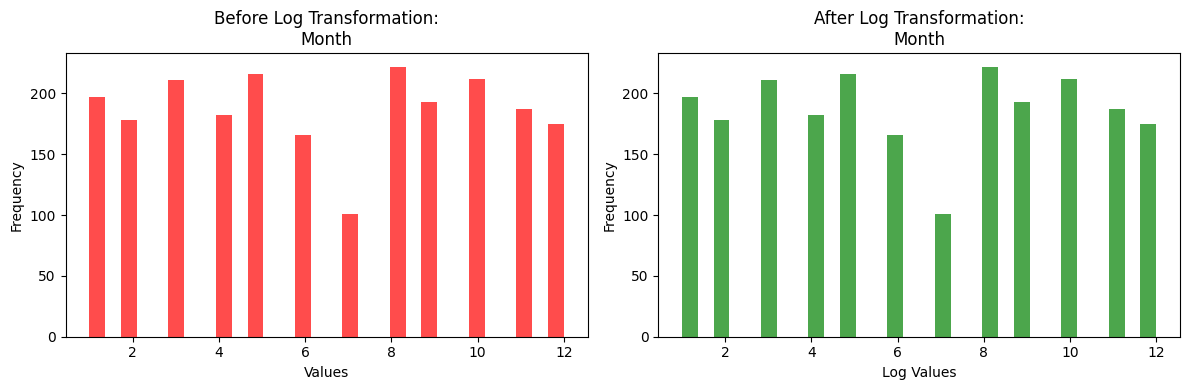

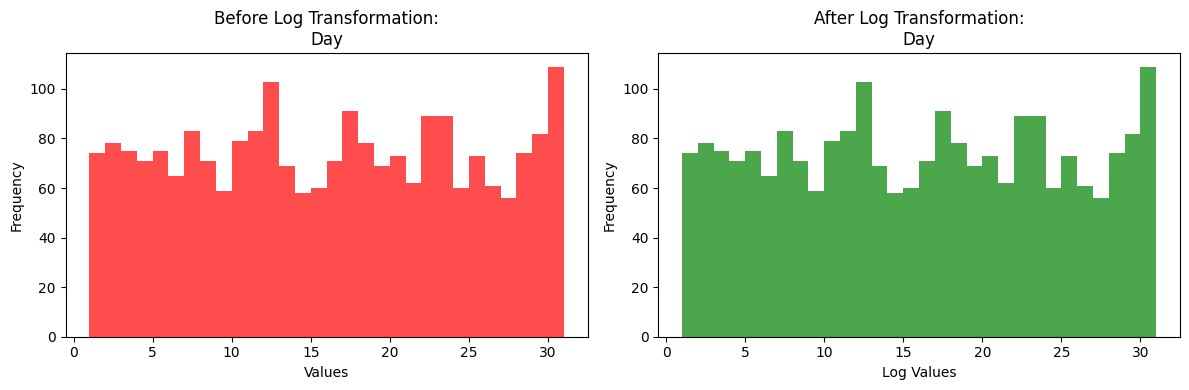

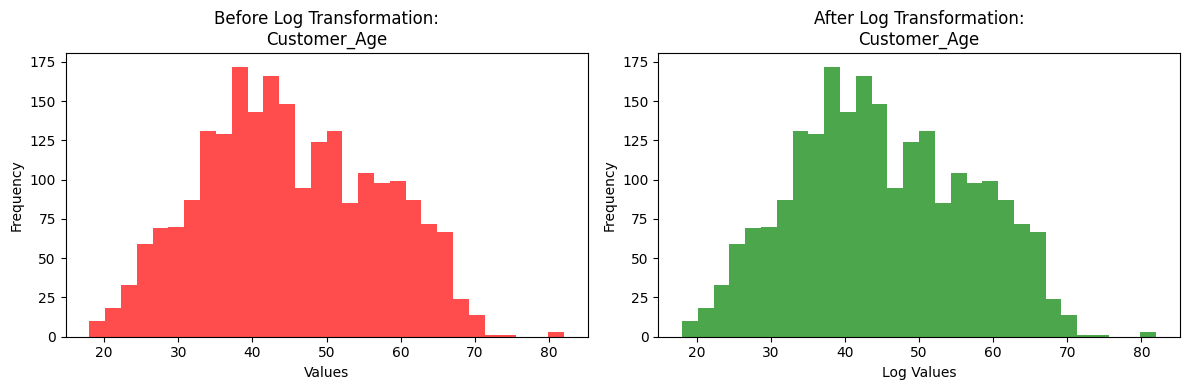

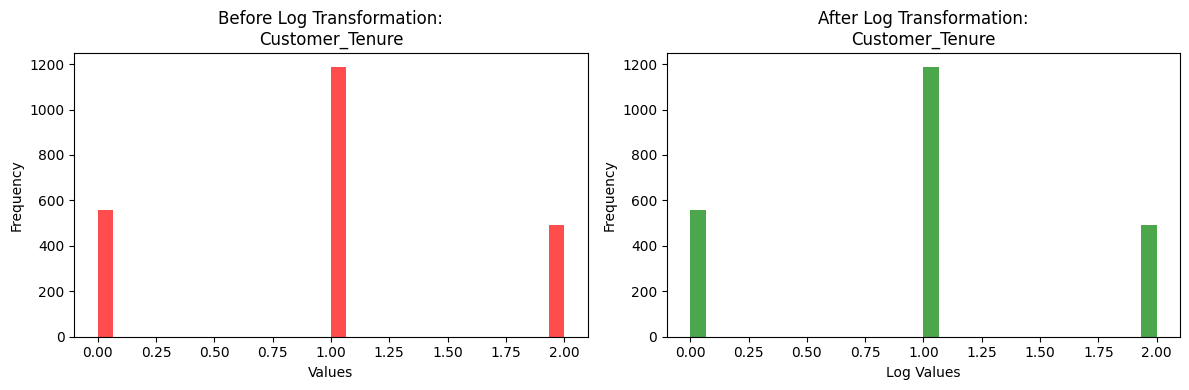

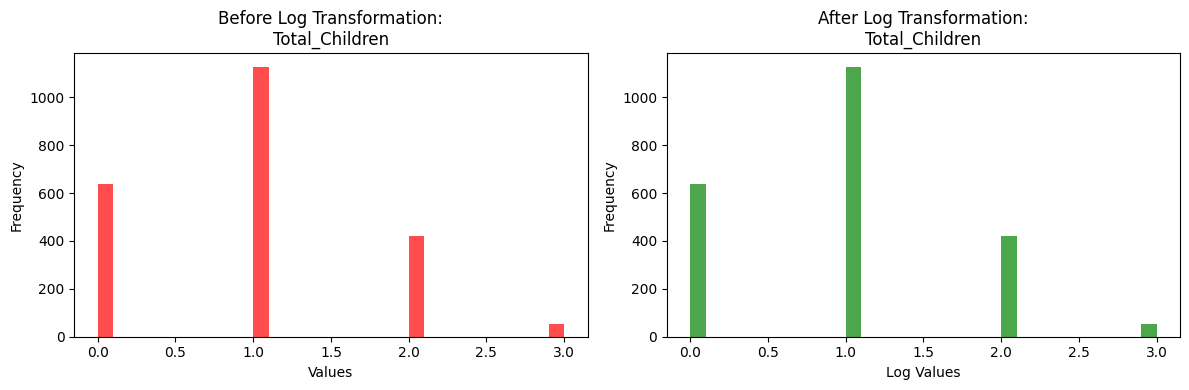

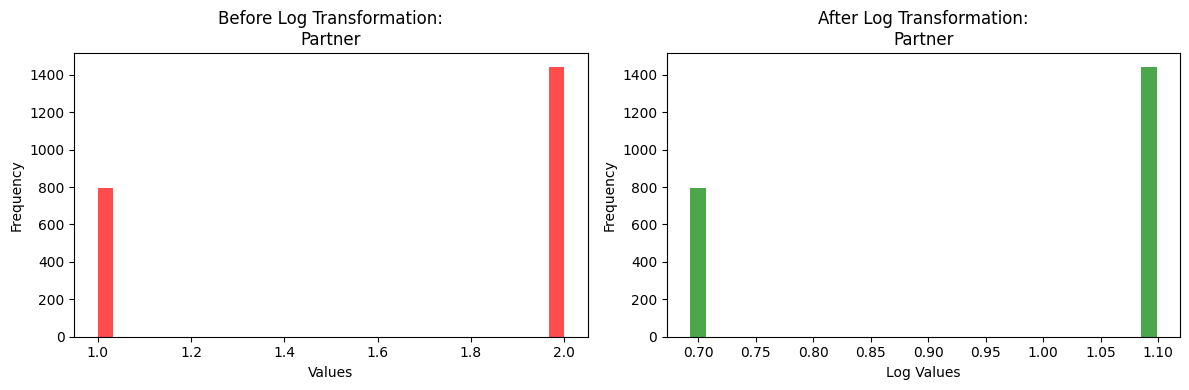

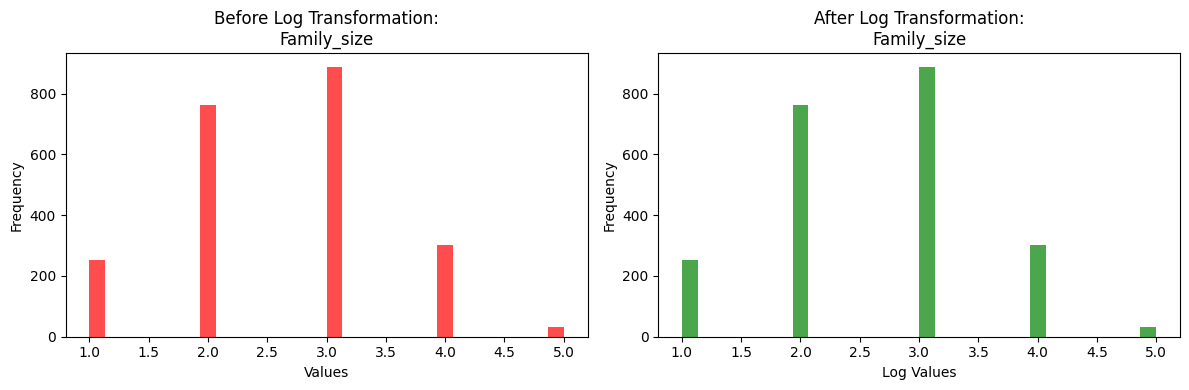

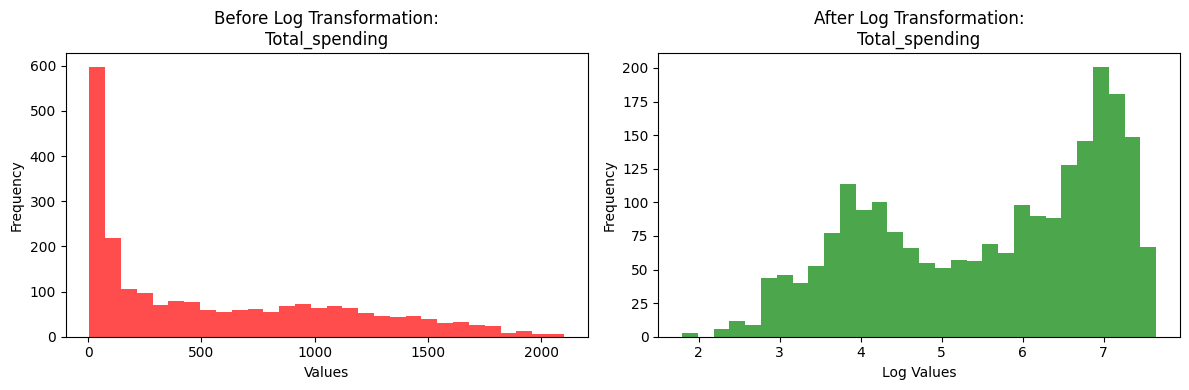

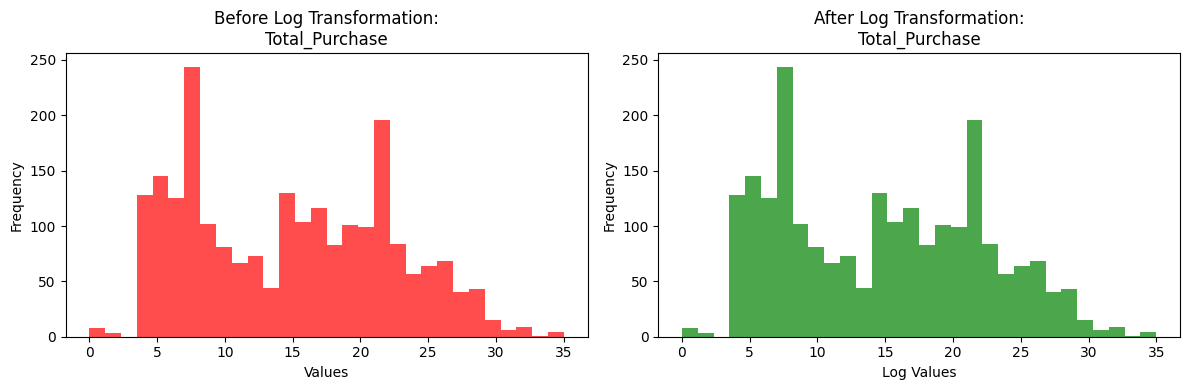

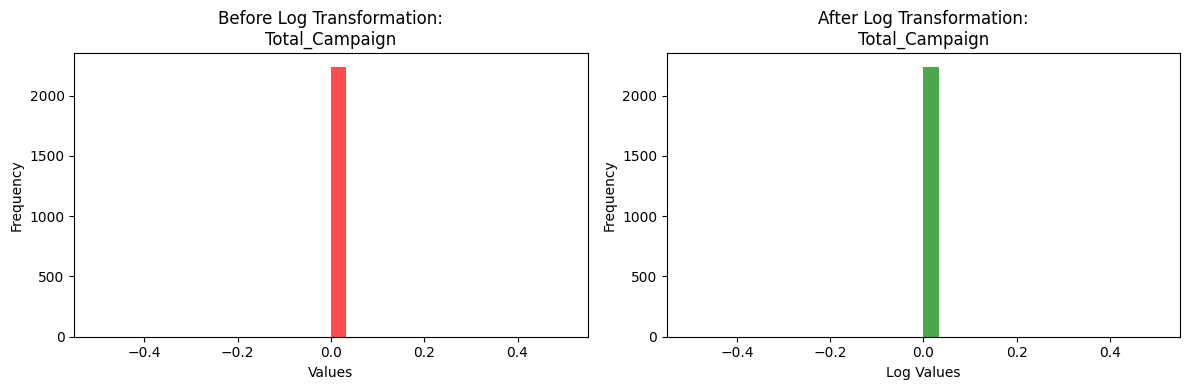

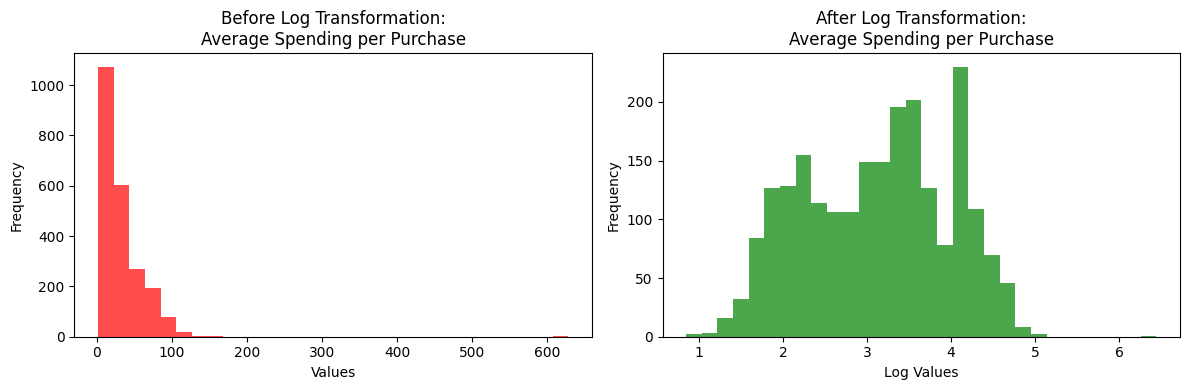

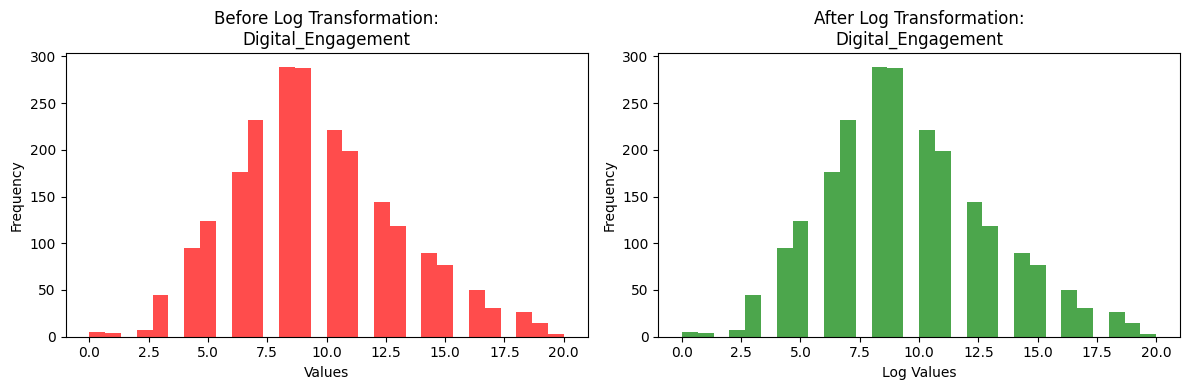

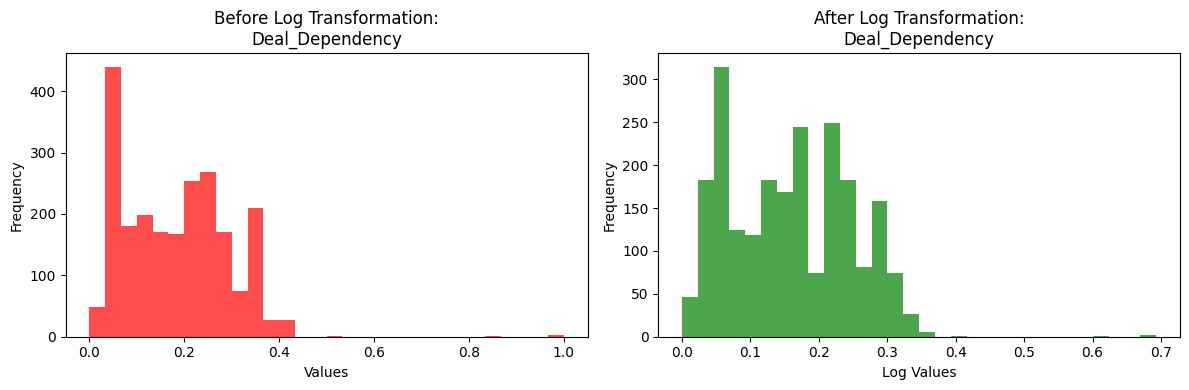

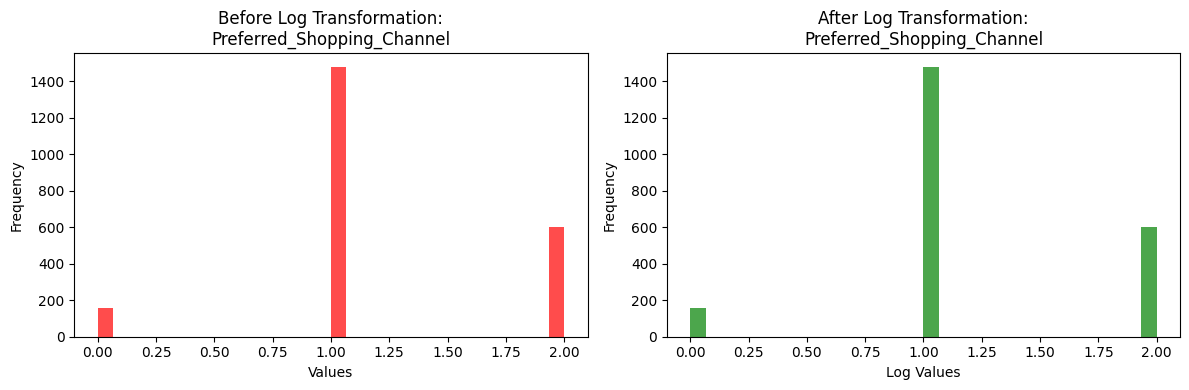

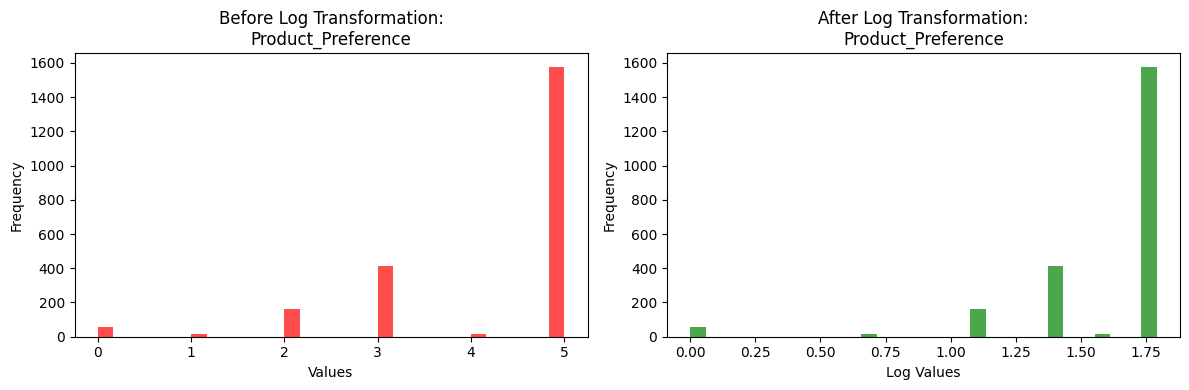

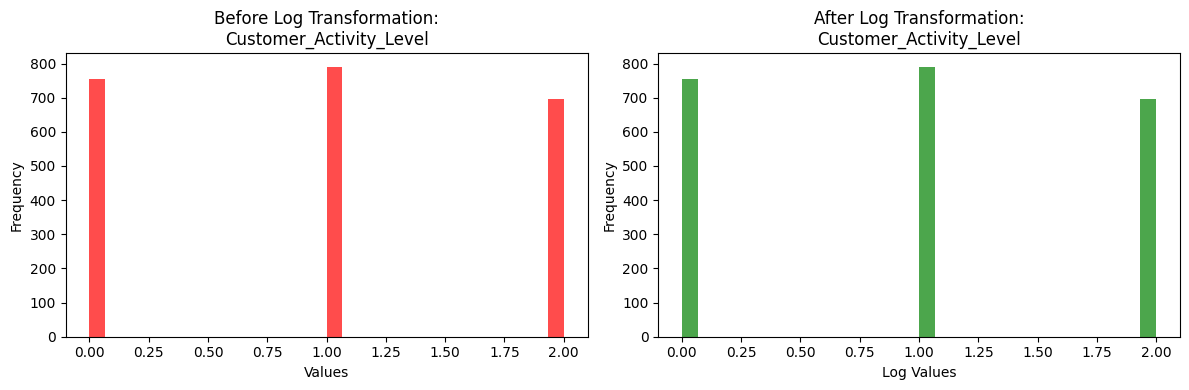

In [307]:
import matplotlib.pyplot as plt

for col in num_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left Graph: Before Transformation (Red)
    axes[0].hist(df_clustring[col], bins=30, color='red', alpha=0.7)
    axes[0].set_title(f"Before Log Transformation:\n{col}")
    axes[0].set_xlabel("Values")
    axes[0].set_ylabel("Frequency")
    
    # Right Graph: After Transformation (Green) 
    axes[1].hist(df_transform[col], bins=30, color='green', alpha=0.7)
    axes[1].set_title(f"After Log Transformation:\n{col}")
    axes[1].set_xlabel("Log Values")
    axes[1].set_ylabel("Frequency")
    
    # Graphs k darmyan spacing theek karna aur display karna
    plt.tight_layout()
    plt.show()


## Task 5: Feature Scaling

In [308]:
from sklearn.preprocessing import StandardScaler
df_scaled=df_transform.copy()
scaler=StandardScaler()
df_scaled[num_col]=scaler.fit_transform(df_transform[num_col])


selected_df=df_scaled.copy()
selected_df.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Family_size,Total_spending,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level
0,-0.458383,1.251776,0.299651,0.307039,0.989643,1.470132,1.442724,1.434322,1.455038,1.121518,...,-1.759115,1.219788,1.380023,0.0,1.176601,1.620481,-0.514589,-2.187642,0.512133,1.276773
1,-0.458383,1.251776,-0.263808,-0.383664,-1.213866,-1.000697,-1.415023,-0.874095,-0.986677,-0.921817,...,0.446548,-1.567145,-1.163336,0.0,-1.629866,-0.965311,1.417872,-0.361890,0.512133,-1.211241
2,-0.458383,-0.272125,0.943420,-0.798086,0.768523,1.140985,0.490422,1.383545,0.589966,0.536950,...,-0.656283,0.739374,0.844579,0.0,0.592428,0.758551,-1.255068,-0.361890,0.512133,1.276773
3,-0.458383,-0.272125,-1.204881,-0.798086,-1.213866,-0.391042,-0.694700,-0.063762,-0.530925,-1.045693,...,0.446548,-1.111302,-0.895614,0.0,-1.254015,-0.390691,0.702554,-0.361890,-0.653942,-1.211241
4,1.533425,-0.272125,0.307056,1.550305,0.270284,1.055931,0.442620,0.841975,0.748533,-0.257498,...,0.446548,0.317339,0.576857,0.0,0.026695,0.183930,0.818614,-0.361890,0.512133,0.032766


## Task 6: Feature Engineering Documentation

## Task 7: Preprocessing Pipeline Development

In [309]:
def preprocessing_pipeline(df_raw, refrence_year=2014):
    df = df_raw.copy()
    
    # 1. Missing Value Handling
    df['Income'] = df['Income'].fillna(df['Income'].median())
    
    # 2. Feature Creation (Yeh saare columns function khud banaye ga)
    if 'Year_Birth' in df.columns:
        df['Age'] = refrence_year - df['Year_Birth']
    if 'Dt_Customer' in df.columns:
        df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')
        df['Customer_Tenure'] = refrence_year - df['Dt_Customer'].dt.year
        df['Customer_Tenure'] = df['Customer_Tenure'].fillna(df['Customer_Tenure'].median())
        
    df['Total_Children'] = df['Kidhome'] + df['Teenhome']
    df['Partner'] = df['Marital_Status'].apply(lambda x: 2 if x in ['Married', 'Together'] else 1)
    df['Family_Size'] = df['Partner'] + df['Total_Children']
    
    spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
    df['Total_spending'] = df[spending_cols].sum(axis=1)
    
    purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
    df['Total_Purchase'] = df[purchase_cols].sum(axis=1)
    
    campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
    df['Total_Campaign'] = df[campaign_cols].sum(axis=1)
    
    df['Average Spending per Purchase'] = (df['Total_spending'] / df['Total_Purchase']).fillna(0)
    df['Digital_Engagement'] = df['NumWebPurchases'] + df['NumWebVisitsMonth']
    df['Deal_Dependency'] = (df['NumDealsPurchases'] / df['Total_Purchase']).fillna(0)
    
    total_activity = df['NumWebVisitsMonth'] + df['Total_Purchase']
    df['Customer_Activity_Level'] = pd.qcut(total_activity, q=3, labels=['Low', 'Medium', 'High'])
    df['Preferred_Shopping_Channel'] = df[purchase_cols].idxmax(axis=1).str.replace('Num', '').str.replace('Purchases', '')
    df['Product_Preference'] = df[spending_cols].idxmax(axis=1).str.replace('Mnt', '')
    
   
    return df


In [310]:
final_preprocessed_df = preprocessing_pipeline(df)
final_preprocessed_df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_spending,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level,Family_Size
0,5524.0,1957.0,Graduation,Single,58138.0,0.0,0.0,2012-09-04,58.0,635.0,...,1551.5,22.0,0.0,70.522727,15.0,0.136364,Catalog,Wines,High,1.0
1,2174.0,1954.0,Graduation,Single,46344.0,1.0,1.0,2014-03-08,38.0,11.0,...,27.0,4.0,0.0,6.750000,6.0,0.500000,Store,Wines,Low,3.0
2,4141.0,1965.0,Graduation,Married,71613.0,0.0,0.0,2013-08-21,26.0,426.0,...,776.0,20.0,0.0,38.800000,12.0,0.050000,Store,Wines,High,2.0
3,6182.0,1984.0,Graduation,Married,26646.0,1.0,0.0,2014-02-10,26.0,11.0,...,53.0,6.0,0.0,8.833333,8.0,0.333333,Store,MeatProducts,Low,3.0
4,5324.0,1981.0,Phd,Married,58293.0,1.0,0.0,2014-01-19,94.0,173.0,...,422.0,14.0,0.0,30.142857,10.0,0.357143,Store,Wines,Medium,3.0


## Task 8: Final Dataset Validation

* **Verify Missing Values**

In [311]:
print("Missing Values")
print(selected_df.isnull().sum())

Missing Values
Education                        0
Marital_Status                   0
Income                           0
Recency                          0
MntWines                         0
MntFruits                        0
MntMeatProducts                  0
MntFishProducts                  0
MntSweetProducts                 0
MntGoldProds                     0
NumDealsPurchases                0
NumWebPurchases                  0
NumCatalogPurchases              0
NumStorePurchases                0
NumWebVisitsMonth                0
AcceptedCmp3                     0
AcceptedCmp4                     0
AcceptedCmp5                     0
AcceptedCmp1                     0
AcceptedCmp2                     0
Complain                         0
Response                         0
Age                              0
Year                             0
Month                            0
Day                              0
Customer_Age                     0
Customer_Tenure                  0
Total

* **Verify Duplicate Records , Datatype and Dataset Shape**

In [312]:
print("\nDuplicates")
print(selected_df.duplicated().sum())


print("\nData Types")
print(selected_df.dtypes)


print("\nDataset Shape")
print(selected_df.shape)





Duplicates
202

Data Types
Education                        float64
Marital_Status                   float64
Income                           float64
Recency                          float64
MntWines                         float64
MntFruits                        float64
MntMeatProducts                  float64
MntFishProducts                  float64
MntSweetProducts                 float64
MntGoldProds                     float64
NumDealsPurchases                float64
NumWebPurchases                  float64
NumCatalogPurchases              float64
NumStorePurchases                float64
NumWebVisitsMonth                float64
AcceptedCmp3                     float64
AcceptedCmp4                     float64
AcceptedCmp5                     float64
AcceptedCmp1                     float64
AcceptedCmp2                     float64
Complain                         float64
Response                         float64
Age                              float64
Year                         

* **Check Why duplicate record occurs Again**

In [313]:

temp = df[["ID"] + list(df_transform.columns)]

print("Duplicates with ID:", temp.duplicated().sum())
print("Duplicates without ID:", df_transform.duplicated().sum())

print("The Reason of again occur duplicate records is removing ID column")

Duplicates with ID: 0
Duplicates without ID: 202
The Reason of again occur duplicate records is removing ID column


* **Remove Duplicate Records**

In [314]:
print("Duplicates Before:", selected_df.duplicated().sum())

selected_df = selected_df.drop_duplicates()

print("Duplicates After:", selected_df.duplicated().sum())

print("Final Shape:", selected_df.shape)

Duplicates Before: 202
Duplicates After: 0
Final Shape: (2038, 40)


* **Verify Scaling**

In [315]:
print("Verify Scaling")
selected_df.describe()

Verify Scaling


,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Family_size,Total_spending,Total_Purchase,Total_Campaign,Average Spending per Purchase,Digital_Engagement,Deal_Dependency,Preferred_Shopping_Channel,Product_Preference,Customer_Activity_Level
count,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,...,2038.000000,2038.000000,2038.000000,2038.0,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000,2038.000000
mean,-0.001479,0.003044,0.003705,0.000341,-0.001391,0.003394,0.000244,-0.005909,0.000491,-0.005818,...,-0.002593,-0.000930,-0.001609,0.0,-0.000616,0.000237,0.001395,0.007202,0.002465,-0.002027
std,1.000060,1.004773,1.001893,1.000263,1.001441,0.998270,1.001761,1.003578,1.000140,1.002351,...,0.999742,1.002209,0.996973,0.0,1.004386,1.006566,1.000772,1.002955,0.992538,0.998911
min,-2.450190,-3.319928,-2.395244,-1.696001,-2.592988,-1.461884,-2.690890,-1.559274,-1.442430,-2.485551,...,-1.759115,-2.636304,-1.966502,0.0,-2.616366,-2.689173,-1.770677,-2.187642,-4.640780,-1.211241
25%,-0.458383,-0.272125,-0.772242,-0.867157,-0.829170,-0.730921,-0.833248,-0.694674,-0.986677,-0.635193,...,-0.656283,-0.938676,-0.895614,0.0,-0.878119,-0.678001,-0.949295,-0.361890,-0.653942,-1.211241
50%,-0.458383,-0.272125,-0.023141,-0.003777,0.273465,0.000042,0.080485,0.040426,0.002271,0.101138,...,0.446548,0.269803,0.041413,0.0,0.102814,-0.103380,-0.062134,-0.361890,0.512133,0.032766
75%,0.537521,1.251776,0.785487,0.859602,0.861363,0.884384,0.877520,0.892915,0.895252,0.763446,...,0.446548,0.905765,0.844579,0.0,0.772225,0.758551,0.702554,1.463862,0.512133,1.276773
max,1.533425,2.775677,3.131672,1.722981,1.353897,1.470132,1.454603,1.434322,1.455038,1.410397,...,2.652211,1.429608,2.718633,0.0,3.822810,3.057033,5.911880,1.463862,0.512133,1.276773


* **Encoding completion**

In [316]:
print("Encoding completion")
selected_df.select_dtypes(include="object")

Encoding completion


""
0
1
2
3
4
...
2233
2235
2237
2238


## SAVE FINAL DATASET

In [317]:
selected_df.to_csv("Customer_Personality_Final_Dataset.csv", index=False)